# Prueba práctica analista de datos - Pragma

## Parte 1

### Definición del problema y contexto de negocio

Pragma desea empezar a trabajar con una marca que presta servicios de banca digital a otras empresas. Dicha marca tiene dentro de sus objetivos como negocio incrementar sus comisiones por utilizar su API de pago en un 50% para el 2022, ellos ganan un 5% de cada transacción que se realice a través de la APP.

Internamente saben que mucho de este crecimiento debe estar bajo estrategias de medios apoyadas en datos, por lo que Pragma le propone segmentar a sus clientes actuales (Comercios y Transacciones) para poder hacer un mejor entendimiento de quiénes son los mejores y la categoría a la que pertenecen estos, así poder crear campañas de marketing mejor segmentadas.

Para lograr esto, su reto como analista de datos es entender la información entregada, analizarla para los últimos 6 meses y lograr una segmentación de los comercios activos en ese periodo de tiempo.

 ***a. Describa el modelo de segmentación implementado y los resultados que obtuvo.***

### Entendimiento de los datos

* Los datos de comercios contienen información de comercios y terminales de los comercios. Un mismo `Id_comercio` puede estar asociado a diferentes `Id_terminal`, aunque no todas tengas ventas registradas.

* Los datos de transacciones contienen información de los comercios por cada mes. Un único comercio aparece una única vez con el valor de transacciones registrado en cada mes dentro del período de Diciembre de 2020 hasta Mayo de 2021.

* 3015 comercios únicos tuvieron al menos 1 transacción dentro del período de tiempo mencionado anteriormente, los cuales se consideran por el momento como comercios activos.

* Al revisar `Fecha 1ra_transaccion` en la tabla de comercios, se observa consistencia respecto a la información de transacciones, ya que el rango de fechas coincide con lo observado en esta tabla.

#### Modelo de segmentación 

Con el contexto de negocio presente, se tiene como objetivo aumentar las comisiones generadas por la API, que corresonder al 5% del monto transado. Con esto, se requiere identificar qué comercios concentran mayor actividad reciente, con mayor frecuencia de transacciones y de mayor valor económico, de forma que las estrategias de marketing puedan enfocarse en los comercios con mayor impacto potencial sobre este objetivo.

Se evaluó la posibilidad de utilizar un método no supervisado como K-means clustering, o una metodología RFM (Recencia, Frecuencia, Monto), optando por esta última debido a lo siquiente:

* **Información disponible:** Solo se dispone de 6 meses de información sobre las transacciones de los comercios, lo cual restringe el uso de un modelo como K-means, pero permite calcular recencia, frecuencia y monto de forma directa.

* **Objetivo de negocio:** RFM permite obtener información del comportamiento de los comercios de manera más directa hacia el objetivo de incrementar las comisiones en un 50%.

* **Relación con comisiones:** Como la comisión es proporcional al monto transado (5%), incorporar el monto como dimensión del modelo permite priorizar los comercios que representan un mayor potencial económico para la API.

#### Análisis Descriptivo y Exploratorio

* Durante el mes de marzo de 2021 se concentra gran parte de la activación de los comercios. De los 3015 comercios activos de la tabla transacciones, 2009 registran su primera transacción en ese mes, mientras que solo 520 comercios registran su primera transacción en febrero de 2021, 223 en enero de 2021 y 198 en diciembre de 2020.

* Se observó un incremento de los comercios activos, pasando de 198 comercios activos en diciembre de 2020 a más de 2000 a partir de marzo de 2021. Esto permite concluir que no todos tuvieron una ventana de exposición de seis meses completos. Esta diferencia en la antigüedad debe considerarse al construir e interpretar la frecuencia (F) del modelo RFM, ya que los comercios más recientes han tenido menos oportunidad de acumular transacciones que aquellos con mayor antigüedad.

* La actividad de los comercios varía a lo largo de los 6 meses, teniendo que la mayor parte de los comercios estuvieron activos durante 3 meses. Hay 550 comercios que registran transacciones durante solo 1 mes (18.2%), 537 en dos meses (17.9%), 1322 en tres meses (43.8%), 361 en cuatro meses (12%), 147 en cinco meses (4.9%) y solo 98 durante los seis meses completos (3.3%).

### Preparación de los datos

* **Período de reporte y comercios activos:** El análisis se enfoca en el período de tiempo de Diciembre de 2020 hasta Mayo de 2021, y se considera un comercio activo, si este tuvo al menos una transacción durante dicho período, contando con 3015 comercios activos.

* **Consolidación de los datos:** Se consolidan los datos de comercios, agrupando por `Id_comercio` para obtener un registro por comercio. En este proceso se calculan `monto_ventas_cumulado` y `monto_ventas_ultimo_mes` sumando los valores entre terminales de un comercio; `Id_terminal` se cuenta como valores únicos para obtener `cant_terminales`. `Fecha de creacion comercio` y `Fecha 1ra_transaccion` se toman como el primer y el mínimo valor por comercio y luego se usan para calcular `meses_antiguedad_creacion_comercio` y `meses_antiguedad_transacciones`. Las variables descriptivas por comercio se mantienen. Para transacciones, se agrupa por `Id_comercio` para construir `transacciones_6m` que es la suma de transacciones en los 6 meses, `meses_activos`  que serían meses distintos con actividad en el comercio, `ultima_actividad` que es el mes más reciente con transacciones del comercio y `transacciones_ultimo_mes` que serían las ctransacciones registradas en mayo de 2021 por comercio. Finalmente se calcula `transacciones_por_mes_activo` como transaccione sen los ultimos 6 meses sobre los meses activos del comercio, y por último `recencia` como los meses entre la última actividad del comercio y el último mes de infomación disponible (mayo 2021). Al final todo  se consolida en un único conjunto de datos para la segmentación.

* **Calidad de datos:** Se identificó que, del total de comercios, 459 presentan actividad en mayo según la tabla de transacciones pero tienen monto igual a cero en la tabla de comercios (`monto_ventas_ultimo_mes = 0`), y 154 presentan monto mayor a cero sin actividad registrada en transacciones para ese mes. Esta inconsistencia se debe a que ambos cálculos provienen de fuentes distintas.

### Segmentación de clientes - RFM (Recencia, Frecuencia, Valor Monetario)

El análisis RFM es un tipo de segmentación de tipo conductual que utiliza las métricas de recencia, frecuencia y valor monetario para realizar una clasificación.

#### Construcción de los Scores

* **R_score (Recencia):** mide qué tan reciente fue la última transacción de un comercio respecto al mes más reciente contemplado (mayo de 2021), siendo `recencia` la cantidad de meses entre la última actividad del comercio y el mes de mayo de 2021. Un puntaje alto identifica comercios activos y un puntaje bajo señala comercios que han reducido o parado sus transacciones por la API. Para el caso contiene valores discretos de cero a 5, por lo que el score se asigno directamente a partir de estos valores.

* **F_score (Frecuencia):** mide qué tan seguido transacciona un comercio, mediante el total de transacciones registradas en el período análisis (`transacciones_6m`); un puntaje alto indica un comercio que utiliza más la API. Presentaba suficiente variabilidad en los datos así que el cálculo del score se asignó a partir de cuantiles, obteniendo grupos homogéneos.

* **M_score (Monto):** mide el valor económico reciente generado por un comercio, a partir de `Monto ventas Acumulado` como la suma del monto total transado por el comercio entre diciembre de 2020 y mayo de 2021. Si la comisión es 5% de cada transacción realizada, un puntaje alto identifica a los comercios que generan mayor comisión. Esta variable presentó una distribución con solo 0.4% de comercios sin monto acumulado y 2440 valores distintos entre los 3015 comercios, con lo que se utilizó cuantiles estándar, obteniendo 5 grupos balanceados de 603 comercios cada uno.

#### Score RFM

El score final se determina como un promedio entre los puntajes: 

$$ RFM_{score} = \frac{(R_{score} + F_{score} + M_{score})}{3}$$

#### Definición de los segmentos

A partir de los puntajes individuales (R_score, F_score, M_score, cada uno en escala 1-5), se definieron las siguientes reglas, considerando "alto" un puntaje mayor o igual a 4 y "bajo" un puntaje menor o igual a 2:

<div align="center">

| Segmento | Regla | Interpretación de negocio |
|---|---|---|
| Alto valor | R>=4, F>=4, M>=4 | Comercios activos recientemente, con alta frecuencia y monto acumulado elevado |
| En riesgo | R<=2, F>=3, M>=3 | Comercios con buen desempeño histórico en frecuencia y monto, pero inactivos recientemente |
| Nuevos / bajo desarrollo | R>=4, F<=2, M<=2 | Comercios activos recientemente, aún sin acumular volumen ni monto significativo |
| Baja actividad | R<=2, F<=2, M<=2 | Comercios inactivos recientemente y con bajo desempeño histórico |
| Estándar | Resto de combinaciones | Comercios sin comprotamiento extremo alto o bajo |

</div>

Esta forma de definir segmentos sigue el estándar de RFM: tras calcular los puntajes de Recencia, Frecuencia y valor Monetario, cada componente se evalúa en una escala numérica, típicamente de 1 a 5, para luego combinarlos en un Score RFM que indica el nivel general de valor o compromiso del cliente.  El método de asignación de puntajes por cuantiles busca que los segmentos se ajusten automáticamente a la distribución real de los datos. 

La escala de 1 a 5 utilizada es consistente con el tamaño de la base de comercios analizada, dado que se recomienda una escala de 1 a 5 para bases de clientes de gran tamaño, mientras que bases más pequeñas suelen usar escalas de 3 o 4 grupos. 

#### Resultados

Del modelo de segmentación RFM se concluye que:

*  28.8% de los comercios correspondiente a el segmento de Alto Valor concentran 75.4% del monto transado acumulado en los seis meses analizados. Para lograr el objetivo de incrementar en un 50% las comisiones por uso de la API para el año 2022, este segmento debería tener prioridad en las estrategias de marketing a desarrollar.

* Los segmentos Estándar y Nuevos o bajo desarrollo agrupan el 51.2% y 14.4% de los comercios, respectivamente. Estos ocmercios generaron un total del 24.3% del valor monetario transado por medio de la API. Sus estrtategias deberían enfocarse en mayor uso de la API y los montos, para desarrollar los comercios y buscar que evoluciones como comercios de Alto Valor.

* Solo un 5.6% de los comercios tienen baja actividad en la API o están en riesgo al haber tenido mayor actividad que fue cesando, asi que si bien representan una oportunidad, no serían el foco en pro de incrementar las comisiones. Podrían considerarse para estrategias de marketing enfocadas en reactivación.

<div align="center">

| Segmento | Comercios | Monto acumulado | Monto último mes | Recencia media | Transacciones media | % Comercios | % Monto acumulado |
| ---- | ---- | ---- | ---- | ---- | ---- | ---- | ---- |
| Alto valor | 868  | $9.980.316.354 | $1.496.128.304 | 0.02 | 57.54 | 28.8% | 75.4% |
| Estándar   | 1545 | $3.057.465.682 | $497.799.436 | 0.70 | 10.42 | 51.2% | 23.1% |
| Nuevos o bajo desarrollo | 433 | $152.423.591 | $24.734.410 | 0.37 | 4.14 | 14.4% | 1.2% |
| En riesgo | 5 | $31.846.050 | $0 | 3.60 | 11.20 | 0.2% |0.2% |
| Baja actividad | 164 | $8.598.655 | $664.000 | 3.59 | 1.59 | 5.4% | 0.1% |

</div>

***b. ¿Qué KPIs y métricas recomienda para hacer un seguimiento al cumplimiento del objetivo?***

### 5. Seguimiento y recomendaciones

El objetivo de negocio de incrementar las comisiones por utilizar su API de pago en un 50% para el 2022, siendo que ellos ganan un 5% de cada transacción que se realice a través de la APP. Con esto presente, el seguimiento y los indicadores deberían enfocarse en responder estas preguntas:

1. ¿Cuánta comisión se genera?
2. ¿De dónde viene esta comisión que se está generando?
3. ¿Cuál es el comporatmiento de la comisión generada en el tiempo?

Para esto se propone lo siguiente la construcción de un tablero de seguimiento pensado para dar respuesta a estas preguntas y con las siguientes consideraciones:

#### KPI principal

Comisión total generada (5% del monto transado), mostrada como Comisión Acumulada y Comisión del Último Mes. Se puede descomponer en distintos filtros como segmento RFM, Ciudad o categoría del comercio, permitiendo identificar cómo se distribuye comisión generada según las características de los comercios. Adicional, se propone revisar específicamente el % de comisión en el segmento de comercios de alto valor, para identificar su distribución

Nota: Para un ejercicio de seguimiento continuo, se plantea como recomendación otro KPI principal que sería el % de comercios que migran hacia Alto Valor, pero este no se considera para ejercicio ya que solo se cuenta con un corte de datos y no con segmentación histórica. 

#### Otros indicadores viables

* **Comercios activos (total y % del total):** para monitorear el tamaño de la base de comercios que utiliza la API y evaluar si presenta crecimiento o no, durant eel período de tiempo analizado.
* **Transacciones mensuales:** responde al comportamiento de la comisión generada en el tiempo, así como también eprmite ver cuándo hubo mayor activación de los comercios en el uso de la API.

#### Visuales de interés 

* **Resumen general:** Se propone una visión general de los principales indicadores, con el análisis histórico de transacciones y comisión, así como la distribución de esta comisión por segmento. Esto permite entender el comportamiento general y dar una priemra mirada sobre los segmentos que concentran mayor valor.

* **Segmentación RFM:** Se propone presentar el detalle del ejercicio de segmentación RFM, permitiendo profundizar en las características de cada segmento y entender su relación con las variables recencia, frecuencia y comisión generada, que permitieron segmentar los comercios.

* **Análisis comercial y geográfico:** Se propone una página para analizar los comercios según su categoría y ciudad, utilizando los KPIs planteados. Esto permite identificar dónde se concentra la generación de comisión y complementar el análisis de la segmentación realizada con una perspectiva comercial.

Finalmente, se propone incorporar filtros por segmento RFM, categoría, ciudad, entre otros, faciliten al usuario la revisión de los indicadores desde diferentes niveles de detalle y evaluar cómo cambia su comportamiento según las características de los comercios.

***c. Haga un tablero dónde se logre visualizar el historial de las métricas y KPIs de acuerdo a la información suministrada y el resultado del modelo.***

Según el diseño planteado, se construye el tablero de seguimiento utilizando Power BI.

**Archivo:** dashboard.pbix

Desarrollo Parte 1:

In [2]:
import sys
print(sys.version)

3.14.7 (main, Aug 14 2026, 15:39:58) [MSC v.1944 64 bit (AMD64)]


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [4]:
comercios = pd.read_excel('../data/raw/DataTransacciones_PruebasIngreso.xlsx',
                          sheet_name= 'comercios')

transacciones = pd.read_excel('../data/raw/DataTransacciones_PruebasIngreso.xlsx',
                          sheet_name= 'transacciones')


In [5]:
comercios.describe()

,Id_terminal,Monto ventas Acumulado,Monto ventas ultimo mes
count,3071.000000,3.071000e+03,3.071000e+03
mean,1542.891241,4.308255e+06,6.575468e+05
std,888.929849,7.588706e+06,1.514033e+06
min,1.000000,0.000000e+00,0.000000e+00
25%,774.000000,3.070000e+05,0.000000e+00
50%,1543.000000,1.527500e+06,1.035500e+05
75%,2312.500000,4.863800e+06,6.710000e+05
max,3080.000000,8.033020e+07,3.265000e+07


In [6]:
transacciones.describe()

,cantidad transacciones
count,8357.000000
mean,8.155080
std,14.537373
min,1.000000
25%,2.000000
50%,4.000000
75%,9.000000
max,248.000000


In [7]:
print(comercios.shape)
print(transacciones.shape)

print(comercios.head(3))
print(transacciones.head(3))

print(comercios.info())
print(transacciones.info())

#comercios únicos
print(comercios['Id_comercio'].nunique())

transacciones['comercio_mes'] = (transacciones['Id_comercio'].astype(str) + '_' + transacciones['mes-anio transaccion'].astype(str))
print(transacciones['comercio_mes'].nunique())

(3071, 10)
(8357, 4)
  Id_comercio Fecha vinculación datafono Fecha de creacion comercio  \
0  Y3CW1ZFJLG       mar. 31, 2021 9:15am      mar. 30, 2021 12:13pm   
1  7S8X7JJ9WB      mar. 26, 2021 12:02pm      mar. 26, 2021 11:27am   
2  K9QUG2O46W      mar. 18, 2021 12:00pm      mar. 18, 2021 11:46am   

           Categoria comercio Sub Categoria comercio  Id_terminal  \
0  Belleza y cuidado personal       Salón de belleza         1278   
1         Comercio detallista                   Otro         2230   
2         Comercio detallista      Ropa / Accesorios         1597   

         Ciudad Fecha 1ra_transaccion  Monto ventas Acumulado  \
0  Bogotá  D.C.  abr. 1, 2021 11:57am                  397150   
1  Bogotá  D.C.  abr. 15, 2021 2:36pm                 1729200   
2  Bogotá  D.C.  abr. 15, 2021 4:42pm                  777000   

   Monto ventas ultimo mes  
0                        0  
1                        0  
2                    88000  
  Id_comercio mes-anio transaccion  cant

In [8]:
meses = {'ene.':'Jan', 'feb.':'Feb', 'mar.':'Mar', 'abr.':'Apr', 'may.':'May', 'jun.':'Jun', 'jul.':'Jul', 'ago.':'Aug', 'sep.':'Sep', 'oct.':'Oct', 'nov.':'Nov', 'dic.':'Dec'}

comercios['Fecha de creacion comercio'] = (comercios['Fecha de creacion comercio'].replace(meses, regex=True))
comercios['Fecha 1ra_transaccion'] = (comercios['Fecha 1ra_transaccion'].replace(meses, regex=True))

comercios['Fecha de creacion comercio'] = pd.to_datetime(comercios['Fecha de creacion comercio'], format='mixed')
comercios['Fecha 1ra_transaccion'] = pd.to_datetime(comercios['Fecha 1ra_transaccion'], format='mixed')

In [9]:
comercios['Fecha de creacion comercio']

0      2021-03-30 12:13:00
1      2021-03-26 11:27:00
2      2021-03-18 11:46:00
3      2021-03-20 14:48:00
4      2021-03-15 13:02:00
               ...        
3066   2021-03-11 10:34:00
3067   2021-03-16 14:24:00
3068   2021-03-02 16:40:00
3069   2021-01-04 16:45:00
3070   2021-02-23 16:41:00
Name: Fecha de creacion comercio, Length: 3071, dtype: datetime64[us]

In [10]:
comercios['Fecha de creacion comercio'].head()

0   2021-03-30 12:13:00
1   2021-03-26 11:27:00
2   2021-03-18 11:46:00
3   2021-03-20 14:48:00
4   2021-03-15 13:02:00
Name: Fecha de creacion comercio, dtype: datetime64[us]

In [11]:
comercios.groupby('Id_comercio')['Id_terminal'].nunique().describe()

count    3015.000000
mean        1.018574
std         0.159794
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
max         5.000000
Name: Id_terminal, dtype: float64

In [12]:
ids_comercios = set(comercios['Id_comercio'].unique())
ids_transacciones = set(transacciones['Id_comercio'].unique())

In [13]:
print(ids_comercios - ids_transacciones)
print(sorted(transacciones['mes-anio transaccion'].unique()))
transacciones['mes'] = pd.to_datetime(transacciones['mes-anio transaccion'], format='%m-%Y')

set()
['1-2021', '12-2020', '2-2021', '3-2021', '4-2021', '5-2021']


In [14]:
transacciones['mes'].min(), transacciones['mes'].max()

(Timestamp('2020-12-01 00:00:00'), Timestamp('2021-05-01 00:00:00'))

In [15]:
transacciones.groupby('mes')['Id_comercio'].nunique()

mes
2020-12-01     198
2021-01-01     353
2021-02-01     887
2021-03-01    2737
2021-04-01    2095
2021-05-01    2087
Name: Id_comercio, dtype: int64

In [16]:
transacciones['Id_comercio'].nunique()

3015

In [17]:
# cant de mese sque estuvieron activos los comercios que hicieron transacciones en los ult 6 meses
meses_activos = (transacciones.groupby('Id_comercio')['mes'].nunique())
meses_activos.value_counts().sort_index()
# meses_activos.value_counts(normalize=True).sort_index() * 100

mes
1     550
2     537
3    1322
4     361
5     147
6      98
Name: count, dtype: int64

In [18]:
primera_actividad = (transacciones.groupby('Id_comercio')['mes'].min())
primera_actividad.value_counts().sort_index()

mes
2020-12-01     198
2021-01-01     223
2021-02-01     580
2021-03-01    2009
2021-04-01       4
2021-05-01       1
Name: count, dtype: int64

In [26]:
comercios_consolidados = comercios.groupby('Id_comercio', as_index=False).agg({'Fecha de creacion comercio': 'first',
                                                                                'Fecha 1ra_transaccion': 'min',
                                                                                'Categoria comercio': 'first',
                                                                                'Sub Categoria comercio': 'first',
                                                                                'Ciudad': 'first',
                                                                                'Id_terminal': 'nunique',
                                                                                'Monto ventas Acumulado': 'sum',
                                                                                'Monto ventas ultimo mes': 'sum'})

ultimo_mes = pd.Timestamp('2021-05-01')

comercios_consolidados['meses_antiguedad_creacion_comercio'] = ((ultimo_mes.year - comercios_consolidados['Fecha de creacion comercio'].dt.year) * 12 + (ultimo_mes.month - comercios_consolidados['Fecha de creacion comercio'].dt.month))
comercios_consolidados['meses_antiguedad_transacciones'] = ((ultimo_mes.year - comercios_consolidados['Fecha 1ra_transaccion'].dt.year) * 12 + (ultimo_mes.month - comercios_consolidados['Fecha 1ra_transaccion'].dt.month))

comercios_consolidados = comercios_consolidados.rename({'Id_terminal': 'cant_terminales'}, axis = 1)

In [27]:
comercios_consolidados.head()

,Id_comercio,Fecha de creacion comercio,Fecha 1ra_transaccion,Categoria comercio,Sub Categoria comercio,Ciudad,cant_terminales,Monto ventas Acumulado,Monto ventas ultimo mes,meses_antiguedad_creacion_comercio,meses_antiguedad_transacciones
0,003QDVFJCJ,2021-03-26 12:17:00,2021-03-26 12:42:00,Comercio detallista,Ropa / Accesorios,Bogotá D.C.,1,6542000,1240000,2,2.0
1,008LJH6YHN,2021-02-10 15:15:00,2021-02-10 15:34:00,Belleza y cuidado personal,Spa,Bogotá D.C.,1,4380000,1102000,3,3.0
2,00B3DGV62G,2021-03-03 15:09:00,2021-03-03 15:30:00,Comercio detallista,Auto partes,Bogotá D.C.,1,11892500,1297000,2,2.0
3,00ILW1BB3Y,2021-03-24 12:33:00,2021-03-24 12:51:00,Comercio detallista,Tienda naturista,Bogotá D.C.,1,372500,74500,2,2.0
4,01AK7UX4UU,2021-03-30 13:40:00,2021-03-30 13:52:00,Comercio detallista,Tecnología,Mosquera,1,165500,0,2,2.0


In [28]:
transacciones['transacciones_ultimo_mes'] = np.where(transacciones['mes'] == pd.Timestamp('2021-05-01'), transacciones['cantidad transacciones'], 0)

agregacion_transacciones = (transacciones.groupby('Id_comercio').agg(transacciones_6m=('cantidad transacciones', 'sum'), # total transacciones en los 6 meses FRECUENCIA
                                                                    meses_activos=('mes', 'nunique'),                     # teimpo activo del comercio
                                                                    ultima_actividad=('mes', 'max'),
                                                                    transacciones_ultimo_mes =('transacciones_ultimo_mes', 'sum')).reset_index())

# transacciones por cad mes activo
agregacion_transacciones['transacciones_por_mes_activo'] = (agregacion_transacciones['transacciones_6m'] / agregacion_transacciones['meses_activos'])

# cant meses desde la ultima act
agregacion_transacciones['recencia'] = ((ultimo_mes.year - agregacion_transacciones['ultima_actividad'].dt.year) * 12 + (ultimo_mes.month - agregacion_transacciones['ultima_actividad'].dt.month)) # RECENCIA

agregacion_transacciones.head()

,Id_comercio,transacciones_6m,meses_activos,ultima_actividad,transacciones_ultimo_mes,transacciones_por_mes_activo,recencia
0,003QDVFJCJ,30,3,2021-05-01,16,10.000000,0
1,008LJH6YHN,10,4,2021-05-01,2,2.500000,0
2,00B3DGV62G,65,3,2021-05-01,21,21.666667,0
3,00ILW1BB3Y,8,3,2021-05-01,5,2.666667,0
4,01AK7UX4UU,4,2,2021-04-01,0,2.000000,1


In [29]:
data_segmentacion = comercios_consolidados.merge(agregacion_transacciones, on='Id_comercio', how='inner')

data_segmentacion.shape
data_segmentacion.columns
# data_segmentacion.info()
# data_segmentacion.isna().sum()

Index(['Id_comercio', 'Fecha de creacion comercio', 'Fecha 1ra_transaccion',
       'Categoria comercio', 'Sub Categoria comercio', 'Ciudad',
       'cant_terminales', 'Monto ventas Acumulado', 'Monto ventas ultimo mes',
       'meses_antiguedad_creacion_comercio', 'meses_antiguedad_transacciones',
       'transacciones_6m', 'meses_activos', 'ultima_actividad',
       'transacciones_ultimo_mes', 'transacciones_por_mes_activo', 'recencia'],
      dtype='str')

In [30]:
data_segmentacion.describe().T

,count,mean,min,25%,50%,75%,max,std
Fecha de creacion comercio,3015,2021-02-26 13:29:33.870646,2020-07-08 22:46:00,2021-02-15 12:41:00,2021-03-10 10:38:00,2021-03-18 16:09:00,2021-03-31 19:35:00,NaN
Fecha 1ra_transaccion,3004,2021-03-01 02:17:41.524634,2020-12-05 11:43:00,2021-02-16 14:07:30,2021-03-10 12:42:00,2021-03-19 11:02:30,2021-06-12 17:14:00,NaN
cant_terminales,3015.0,1.018574,1.0,1.0,1.0,1.0,5.0,0.159794
Monto ventas Acumulado,3015.0,4388275.400332,0.0,325700.0,1554000.0,4976200.0,104180900.0,7785726.988799
Monto ventas ultimo mes,3015.0,669759.917081,0.0,0.0,110000.0,682450.0,32650000.0,1532529.020657
meses_antiguedad_creacion_comercio,3015.0,2.610614,2.0,2.0,2.0,3.0,10.0,1.097572
meses_antiguedad_transacciones,3004.0,2.530626,-1.0,2.0,2.0,3.0,5.0,0.905487
transacciones_6m,3015.0,22.604312,1.0,3.0,10.0,23.0,740.0,43.201066
meses_activos,3015.0,2.771808,1.0,2.0,3.0,3.0,6.0,1.209754
ultima_actividad,3015,2021-04-12 07:00:46.567164,2020-12-01 00:00:00,2021-04-01 00:00:00,2021-05-01 00:00:00,2021-05-01 00:00:00,2021-05-01 00:00:00,NaN


In [32]:
# segmentacion
resumen = data_segmentacion[['recencia', 'transacciones_6m', 'Monto ventas ultimo mes']].describe(percentiles=[.25, .5, .75, .9, .95, .99])
print(resumen)

# comercios con cero
print((data_segmentacion[['recencia', 'transacciones_6m', 'Monto ventas ultimo mes']] == 0).mean() * 100)

# mucho comercios sin ventas en el ultimo mes afectan el m score asi que separan en un solo grupo

# valores únicos por métrica
data_segmentacion[['recencia', 'transacciones_6m', 'Monto ventas ultimo mes']].nunique()

# solo hay 6 valores único de recencia entonces el puntaje de asigna directo en base con estos valores

          recencia  transacciones_6m  Monto ventas ultimo mes
count  3015.000000       3015.000000             3.015000e+03
mean      0.619569         22.604312             6.697599e+05
std       1.080171         43.201066             1.532529e+06
min       0.000000          1.000000             0.000000e+00
25%       0.000000          3.000000             0.000000e+00
50%       0.000000         10.000000             1.100000e+05
75%       1.000000         23.000000             6.824500e+05
90%       2.000000         53.000000             1.848400e+06
95%       3.000000         86.000000             3.142700e+06
99%       5.000000        191.440000             6.905160e+06
max       5.000000        740.000000             3.265000e+07
recencia                   69.220564
transacciones_6m            0.000000
Monto ventas ultimo mes    40.895522
dtype: float64


recencia                      6
transacciones_6m            180
Monto ventas ultimo mes    1348
dtype: int64

In [33]:
pd.crosstab(data_segmentacion['recencia'] == 0, data_segmentacion['Monto ventas ultimo mes'] == 0)
# hay datos que traen con monto en el último mes pero recencia > 0, y casos con recencia = 0 pero sin monto, por lo que es una inconsistencia, o devoluciones y otras transacciones de los sitemas

Monto ventas ultimo mes,False,True
recencia,,
False,154,774
True,1628,459


In [34]:
data_segmentacion['M_score'] = pd.qcut(data_segmentacion['Monto ventas Acumulado'], 5, labels=[1,2,3,4,5], duplicates='drop')
print(data_segmentacion['M_score'].value_counts().sort_index())

M_score
1    603
2    603
3    603
4    603
5    603
Name: count, dtype: int64


In [35]:
# F Score
# se calculan cuantiles directar ya que hay variabilidad
data_segmentacion['F_score'] = pd.qcut(data_segmentacion['transacciones_6m'], 5,labels=range(1, 6), duplicates='drop')
data_segmentacion['F_score'].value_counts().sort_index()

F_score
1    756
2    566
3    528
4    575
5    590
Name: count, dtype: int64

In [36]:
# R Score
# recencia tiene valores discretos y muchos ceros, así que se asigna el score a partir de los valores exactos
data_segmentacion['R_score'] = data_segmentacion['recencia'].map({0:5, 1:4, 2:3, 3:2, 4:1, 5:1})
data_segmentacion['R_score'].value_counts().sort_index()

R_score
1      77
2     115
3     440
4     296
5    2087
Name: count, dtype: int64

In [37]:
# score general como promedio de los otros
data_segmentacion['RFM_score'] = (
    data_segmentacion['R_score'].astype(int) +
    data_segmentacion['F_score'].astype(int) +
    data_segmentacion['M_score'].astype(int)
) / 3

print(data_segmentacion['RFM_score'].describe())

count    3015.000000
mean        3.428745
std         1.150927
min         1.000000
25%         2.666667
50%         3.666667
75%         4.333333
max         5.000000
Name: RFM_score, dtype: float64


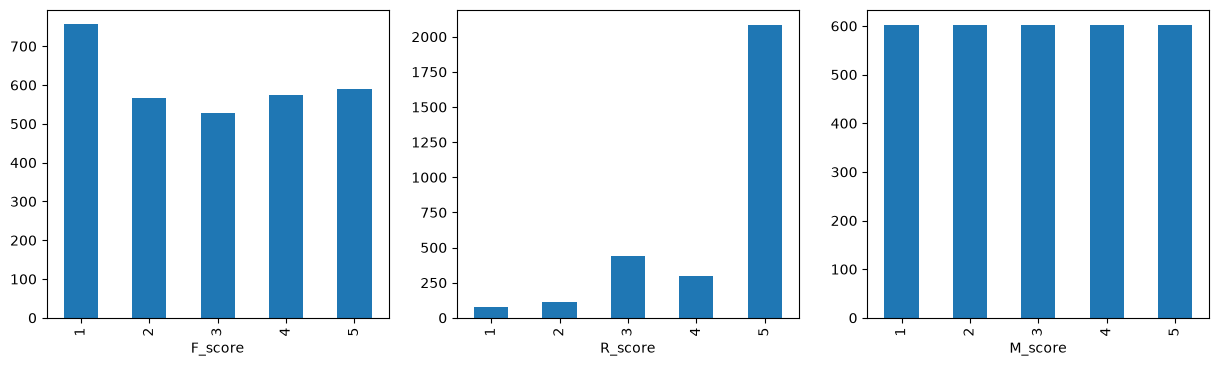

In [38]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

data_segmentacion['F_score'].value_counts().sort_index().plot(kind='bar', ax=ax[0])
data_segmentacion['R_score'].value_counts().sort_index().plot(kind='bar', ax=ax[1])
data_segmentacion['M_score'].value_counts().sort_index().plot(kind='bar', ax=ax[2])

plt.show()

In [39]:
def asignar_segmento(row):
    r, f, m = row['R_score'], row['F_score'], row['M_score']
    if r >= 4 and f >= 4 and m >= 4:
        return 'Alto valor'
    elif r <= 2 and f >= 3 and m >= 3:
        return 'En riesgo'
    elif r >= 4 and f <= 2 and m <= 2:
        return 'Nuevos o bajo desarrollo'
    elif r <= 2 and f <= 2 and m <= 2:
        return 'Baja actividad'
    else:
        return 'Estándar'

data_segmentacion['segmento_rfm'] = data_segmentacion.apply(asignar_segmento, axis=1)

print(data_segmentacion['segmento_rfm'].value_counts())
print((data_segmentacion['segmento_rfm'].value_counts(normalize=True) * 100).round(1))

segmento_rfm
Estándar                    1545
Alto valor                   868
Nuevos o bajo desarrollo     433
Baja actividad               164
En riesgo                      5
Name: count, dtype: int64
segmento_rfm
Estándar                    51.2
Alto valor                  28.8
Nuevos o bajo desarrollo    14.4
Baja actividad               5.4
En riesgo                    0.2
Name: proportion, dtype: float64


In [40]:
resumen_segmentos = data_segmentacion.groupby('segmento_rfm').agg(
    comercios=('Id_comercio','count'),
    monto_acumulado_total=('Monto ventas Acumulado','sum'),
    monto_ultimo_mes_total=('Monto ventas ultimo mes','sum'),
    recencia_media=('recencia','mean'),
    transacciones_media=('transacciones_6m','mean')
).sort_values('monto_acumulado_total', ascending=False)

resumen_segmentos['pct_comercios'] = (resumen_segmentos['comercios'] / resumen_segmentos['comercios'].sum() * 100).round(1)
resumen_segmentos['pct_monto_acumulado'] = (resumen_segmentos['monto_acumulado_total'] / resumen_segmentos['monto_acumulado_total'].sum() * 100).round(1)

resumen_segmentos

,comercios,monto_acumulado_total,monto_ultimo_mes_total,recencia_media,transacciones_media,pct_comercios,pct_monto_acumulado
segmento_rfm,,,,,,,
Alto valor,868,9980316354,1496128304,0.018433,57.541475,28.8,75.4
Estándar,1545,3057465682,497799436,0.702913,10.418770,51.2,23.1
Nuevos o bajo desarrollo,433,152423591,24734410,0.367206,4.140878,14.4,1.2
En riesgo,5,31846050,0,3.600000,11.200000,0.2,0.2
Baja actividad,164,8598655,664000,3.591463,1.585366,5.4,0.1


In [42]:
pct_cero_acum = (data_segmentacion['Monto ventas Acumulado'] == 0).mean() * 100
print(f'{pct_cero_acum:.1f}% de comercios con Monto Acumulado en 0')
print(data_segmentacion['Monto ventas Acumulado'].nunique())

0.4% de comercios con Monto Acumulado en 0
2440


In [43]:
data_segmentacion.to_csv('../data/processed/data_segmentacion.csv', index=False, encoding="utf-8-sig")